The overall goal of this project is to find the set of controls (accelerator position, brake pressed, steering) for an optimised speed input (speed, position).
- Steering data is unavailable, so is currently out of scope.
- FSGP data from 2024 July, potentially over like 2-3 days


In [1]:
# query data from influx. looking at timestamps of 2024 FSGP: 14 - 18 overall, but for smaller data response lets try 14 -16

from data_tools import query
from data_tools.collections import TimeSeries
from datetime import datetime, date, time, timezone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dill
import os
import pytz
from datetime import datetime, time, date

#each 5 seconds
utc_offset_h = 2
start_utc = time(0, 00, 00)  #querying i svancouver time, influxdb gives utc
stop_utc = time(23, 45, 00)
date_start = date(2024, 7, 14)
date_stop = date(2024, 7, 16)

vancouver = pytz.timezone("America/Vancouver")

start_local = vancouver.localize(datetime.combine(date_start, start_utc))
stop_local = vancouver.localize(datetime.combine(date_stop, stop_utc))

start_time = start_local.astimezone(pytz.utc)
stop_time = stop_local.astimezone(pytz.utc)

client = query.DBClient()
mech_brake_pressed: TimeSeries = client.query_time_series(start_time, stop_time, field="MechBrakePressed")
accel_position: TimeSeries =   client.query_time_series(start_time, stop_time, field="AcceleratorPosition")
speed_kph: TimeSeries = client.query_time_series(start_time, stop_time, "MotorRotatingSpeed")



In [2]:
# save collected data

out_dir = os.path.join("../../array_temp", "data", "control_state_fsgp_2024")
os.makedirs(out_dir, exist_ok=True)

brake_path = os.path.join(out_dir, "brake_pressed.bin")
accel_path = os.path.join(out_dir, "acceleration.bin")
speed_path = os.path.join(out_dir, "speed_kph.bin")

filepaths = [brake_path, accel_path, speed_path]
datasets = [mech_brake_pressed, accel_position, speed_kph]

for filepath, data in zip(filepaths, datasets):
    with open(filepath, "wb") as f:
        dill.dump(data, f)


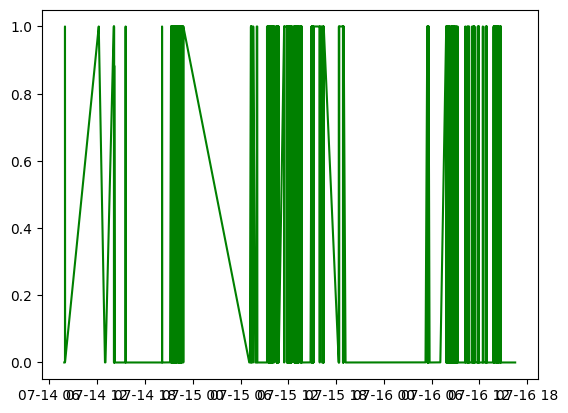

In [8]:
plt.plot(mech_brake_pressed.datetime_x_axis, mech_brake_pressed, color = 'green', label = "Brake Pressed")

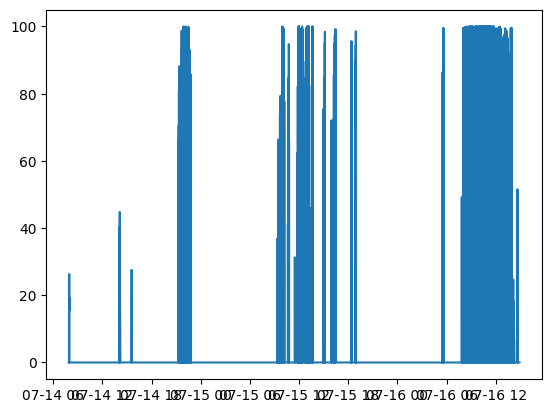

In [9]:
plt.plot(accel_position.datetime_x_axis, accel_position, label = "Accelerator Position")

In [11]:
# accel position and brake pressed are in inconsistent units, so i'll probbaly change them to a 0-1 range.

#using min, max scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_accel_position = scaler.fit_transform(accel_position.reshape(-1, 1))




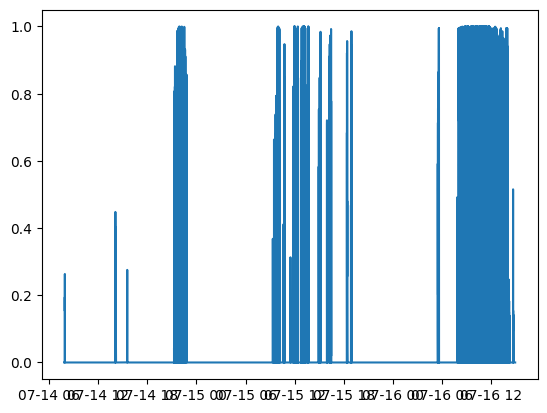

In [14]:
plt.plot(accel_position.datetime_x_axis, scaled_accel_position, label = "Accelerator Position")

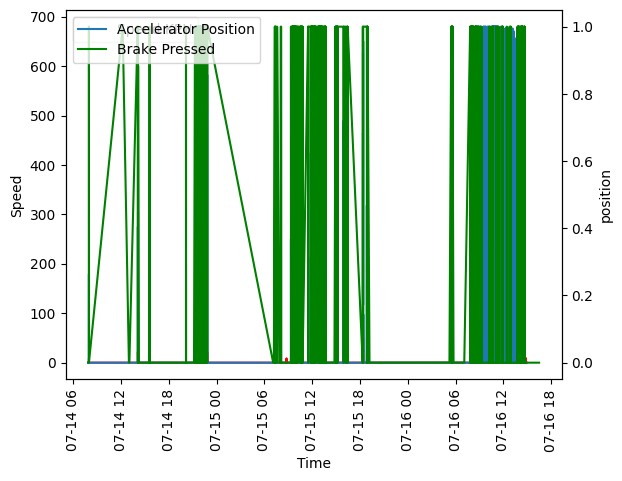

In [15]:
#plot relevant data

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

plt.plot(accel_position.datetime_x_axis, scaled_accel_position, label = "Accelerator Position")
plt.plot(mech_brake_pressed.datetime_x_axis, mech_brake_pressed, color = 'green', label = "Brake Pressed")
ax1.plot(speed_kph.datetime_x_axis, speed_kph, color = 'red', label = "Speed KPH")


ax1.set_xlabel("Time")
ax1.set_ylabel("Speed")
ax_twin.set_ylabel("position")

ax1.tick_params("x", rotation  = 90)


plt.legend(loc = "upper left")
ax1.legend(loc = "upper left")
plt.show()

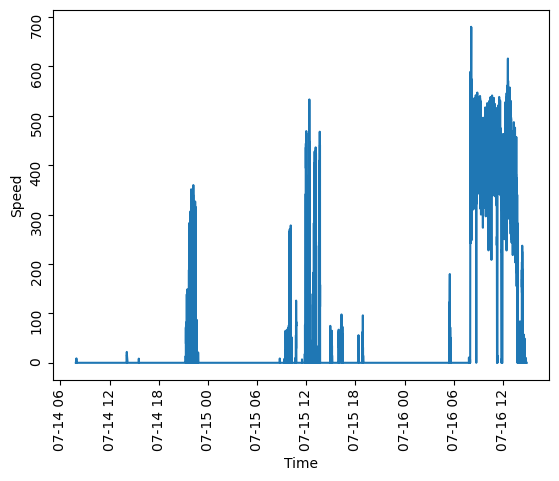

In [7]:
# position is defined as a percentage

plt.plot(speed_kph.datetime_x_axis, speed_kph, label = "Speed KPH")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.tick_params(rotation = 90)

In [ ]:
# in order to get position data, look up miguel's work for localization of fsgp data


# this project is essentially constrained in one lap


#from miguel's code, we find the number of laps done on one day, so let us